In [2]:
import os

print(os.getcwd())

d:\project\AI-Banking-Churn-System\notebooks


In [3]:
import os
import sys

# Move from notebooks/ to project root
project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project Root:", project_root)

Project Root: d:\project\AI-Banking-Churn-System


In [4]:
import pandas as pd

In [5]:
from src.database.queries import get_customer_data

In [6]:
df =get_customer_data()

df.head()

,row_number,customer_id,surname,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df=df.drop(
    columns=[
        "row_number",
        "customer_id",
        "surname",
    ]
)

In [8]:
df["gender"] = df["gender"].map({
    "Female": 0,
    "Male": 1
})

In [9]:
df = pd.get_dummies(
    df,
    columns=["geography"],
    drop_first=int
)

In [10]:
X = df.drop("exited", axis=1)
y = df["exited"]

In [11]:
from src.modeling.model_utils import load_model

model = load_model()

In [12]:
import importlib
import src.explainability.shap_explainer

importlib.reload(src.explainability.shap_explainer)

from src.explainability.shap_explainer import (
    create_shap_explainer,
    plot_summary
)

In [13]:
import shap
import xgboost
import sklearn

print("SHAP:", shap.__version__)
print("XGBoost:", xgboost.__version__)
print("Scikit-learn:", sklearn.__version__)

SHAP: 0.49.1
XGBoost: 3.2.0
Scikit-learn: 1.7.2


In [14]:
import shap


def create_shap_explainer(model, X_background):
    """
    Create SHAP explainer using a background dataset.
    """
    return shap.Explainer(model.predict_proba, X_background)


def explain_customer(explainer, X):
    return explainer(X)


def plot_summary(explainer, X):
    shap_values = explainer(X)
    shap.plots.beeswarm(shap_values[:, :, 1])


def plot_waterfall(explainer, X):
    shap_values = explainer(X)
    shap.plots.waterfall(shap_values[0, :, 1])

In [15]:
explainer = create_shap_explainer(model, X.sample(100, random_state=42))

In [16]:
print(X.dtypes)

credit_score           int64
gender                 int64
age                    int64
tenure                 int64
balance              float64
num_of_products        int64
has_cr_card            int64
is_active_member       int64
estimated_salary     float64
geography_Germany       bool
geography_Spain         bool
dtype: object


In [17]:
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit_score       10000 non-null  int64  
 1   gender             10000 non-null  int64  
 2   age                10000 non-null  int64  
 3   tenure             10000 non-null  int64  
 4   balance            10000 non-null  float64
 5   num_of_products    10000 non-null  int64  
 6   has_cr_card        10000 non-null  int64  
 7   is_active_member   10000 non-null  int64  
 8   estimated_salary   10000 non-null  float64
 9   geography_Germany  10000 non-null  bool   
 10  geography_Spain    10000 non-null  bool   
dtypes: bool(2), float64(2), int64(7)
memory usage: 722.8 KB
None


In [18]:
X = X.astype(float)

In [19]:
print(X.dtypes)

credit_score         float64
gender               float64
age                  float64
tenure               float64
balance              float64
num_of_products      float64
has_cr_card          float64
is_active_member     float64
estimated_salary     float64
geography_Germany    float64
geography_Spain      float64
dtype: object


In [20]:
background = X.sample(200, random_state=42)

explainer = create_shap_explainer(
    model,
    background
)

In [21]:
"""plot_summary(
    explainer,
    X.sample(500, random_state=42)
)"""

'plot_summary(\n    explainer,\n    X.sample(500, random_state=42)\n)'

In [22]:
import importlib
import src.explainability.shap_explainer

importlib.reload(src.explainability.shap_explainer)

from src.explainability.shap_explainer import (
    explain_customer,
    plot_waterfall
)

In [23]:
customer = X.iloc[[25]]

In [24]:
shap_values = explain_customer(
    explainer,
    customer
)

PermutationExplainer explainer: 2it [00:20, 20.36s/it]               


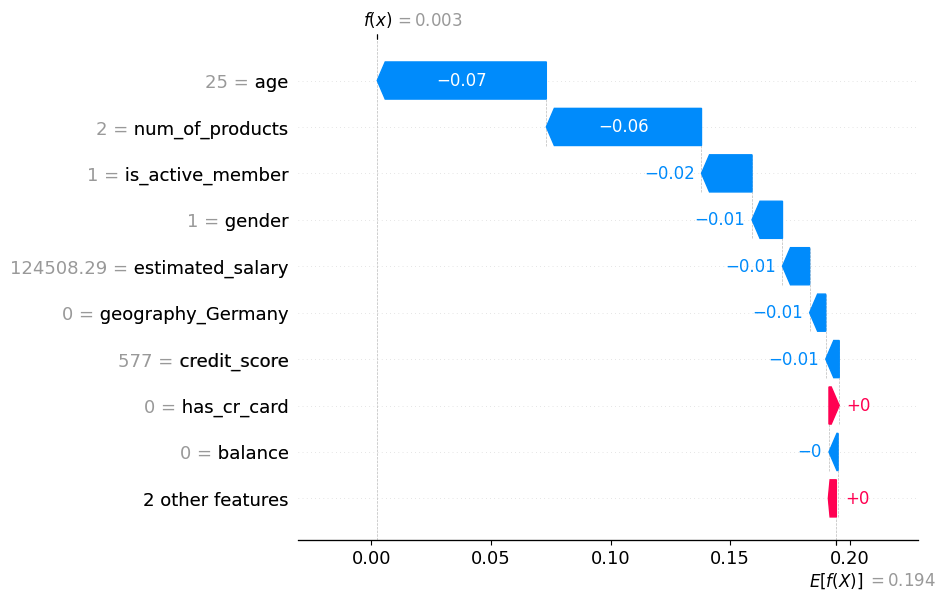

In [25]:
plot_waterfall(
    explainer,
    customer
)

In [26]:
probability = model.predict_proba(customer)[0][1]

prediction = model.predict(customer)[0]

print(f"Prediction : {prediction}")
print(f"Churn Probability : {probability:.2%}")

Prediction : 0
Churn Probability : 0.25%


In [27]:
probs = model.predict_proba(X)[:, 1]

high_risk_index = probs.argmax()

print(high_risk_index)
print(probs[high_risk_index])

2614
0.99926156


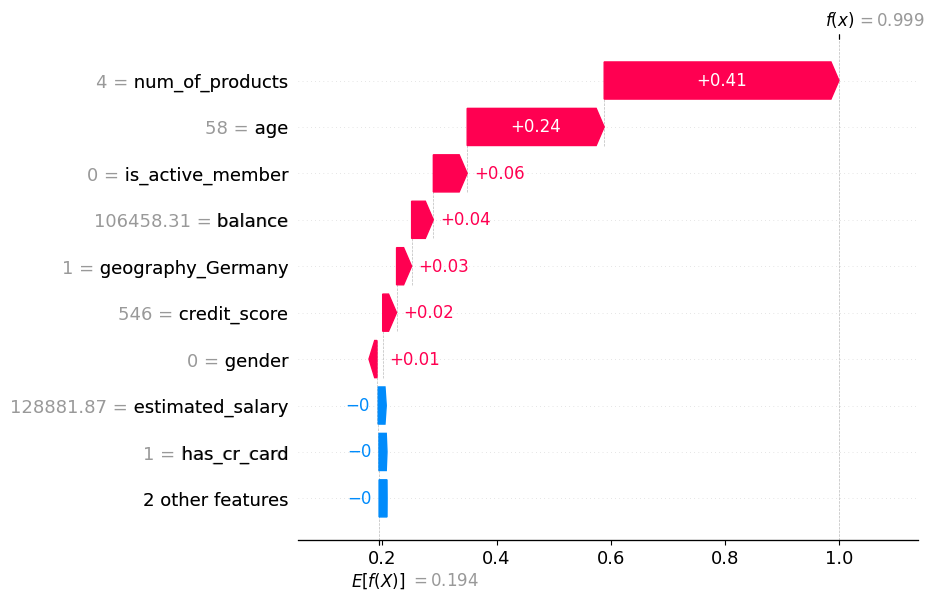

0.99926156


In [28]:
customer = X.iloc[[high_risk_index]]

plot_waterfall(explainer, customer)

print(model.predict_proba(customer)[0][1])

In [29]:
probability = model.predict_proba(customer)[0][1]

prediction = model.predict(customer)[0]

print(f"Prediction : {prediction}")
print(f"Churn Probability : {probability:.2%}")

Prediction : 1
Churn Probability : 99.93%


recommendation engine

In [33]:
from src.recommendation.recommendation_engine import generate_recommendations

In [34]:
customer = X.iloc[[high_risk_index]]

In [35]:
customer_series = customer.iloc[0]

In [36]:
recommendations = generate_recommendations(customer_series)

for i, recommendation in enumerate(recommendations, start=1):
    print(f"{i}. {recommendation}")

1. Launch re-engagement campaign.
2. Assign a relationship manager.
3. Provide personalized financial guidance.
4. Offer senior customer loyalty benefits.
5. Recommend premium banking services.
6. Provide region-specific retention offers.
